In [26]:
import numpy as np
import xarray as xr
import pandas as pd
import sys, os
from glob import glob 
# Gross fix this
sys.path.append(os.path.dirname(os.getcwd())); from utils import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy import ndimage as ndi
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

from scipy.signal import find_peaks


from base64 import b64encode
from IPython.display import HTML
def show_video(video_path):
    video_file = open(video_path, "r+b").read()
    video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
    return HTML(f"""<video width="640" height="480" autoplay loop controls><source src="{video_url}"></video>""")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
good_data_only = [
    ('20211014T120100Z', 'north half good'),
    ('20211014T123100Z', 'north half good. lighting exposure changes'),
    ('20211013T170100Z', 'some lighting'), 
    ('20211014T130100Z', 'north only, some low contrast'),
    ('20211028T153100Z', '')
]
array_8m = xr.load_dataset('../../data/FRF-ocean_waves_8m-array_202110.nc')


In [13]:
# Go through and find all the > SECONDS duration clips
data = []
SECONDS = 60
for time, _ in good_data_only:
    file = os.path.join('../../data/argus', f'ArgusFF_{time}_RectifiedVideo.avi')
    N, W, H, FPS = get_video_shape(file)
    timestack = load_frames(file, dtype=np.uint8)[:, 500:1000, :]
    
    bad_data = np.sum(timestack == 0, axis=2).sum(axis=1)
    good_data = bad_data == bad_data.min()
    edges = np.convolve((np.convolve(good_data, np.ones(FPS * SECONDS + 1)) == FPS * SECONDS + 1),np.array([1, -1]))

    start = np.where(edges == 1)[0]
    end =   np.where(edges == -1)[0]

    data.append({
                'filename': os.path.abspath(file),
                'key': time,
                'good_data': list(zip(start, end)) 
            },
    )
    break
    del timestack
    print(data[-1], (end-start)/FPS/60, 'min')

3.072gb allocated


Building Timestack:   0%|          | 0/3840 [00:00<?, ?it/s]

Building Timestack: 100%|██████████| 3840/3840 [00:11<00:00, 330.29it/s]


In [17]:
ymin, ymax = 0, 1600
for vid in data:
    file = vid['filename']
    slices = vid['good_data']
    N, W, H, FPS = get_video_shape(file)
    timestack = load_frames(file)[:, ymin:ymax]
    N, W, H = timestack.shape
    print(vid['key'])
    xrd = []
    start, end = slices[-1]

    breakers = np.zeros_like(timestack[start:end])
    
    Tp = array_8m.sel(time=pd.to_datetime(vid['key']).tz_localize(None), method='nearest').waveTp.item()
    sec = np.linspace(0, len(breakers)/FPS, len(breakers))
    Tps = sec / Tp


    WRITE_FPS = 5 * FPS

    breakers = lambda_c_algorithm(timestack[start:end])

6.144gb allocated


Building Timestack:   0%|          | 0/3840 [00:00<?, ?it/s]

Building Timestack: 100%|██████████| 3840/3840 [00:19<00:00, 196.87it/s]


20211014T120100Z


100%|██████████| 1043/1043 [07:55<00:00,  2.19it/s]


In [18]:
qb_30s = running_qb(breakers.astype(np.float64), Tp, window_size=FPS*30)

In [19]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Flatten the data and create histogram
flat_data = qb_30s.flatten()
hist, bin_edges = np.histogram(flat_data, bins=100, range=(0, 0.1))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Prepare data for GMM
# Limit the maximum count to keep dataset size manageable
max_count = 1000
scaled_hist = (hist / hist.max() * max_count).astype(int)
X = np.repeat(bin_centers, scaled_hist).reshape(-1, 1)

# Fit Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X)

# Generate points from the GMM
x = np.linspace(0, 0.1, 1000).reshape(-1, 1)
logprob = gmm.score_samples(x)
responsibilities = gmm.predict_proba(x)



Gaussian 1:
  Mean = 0.000600
  Std Dev = 0.001100
  Weight = 0.933516
Gaussian 2:
  Mean = 0.006855
  Std Dev = 0.003091
  Weight = 0.066484


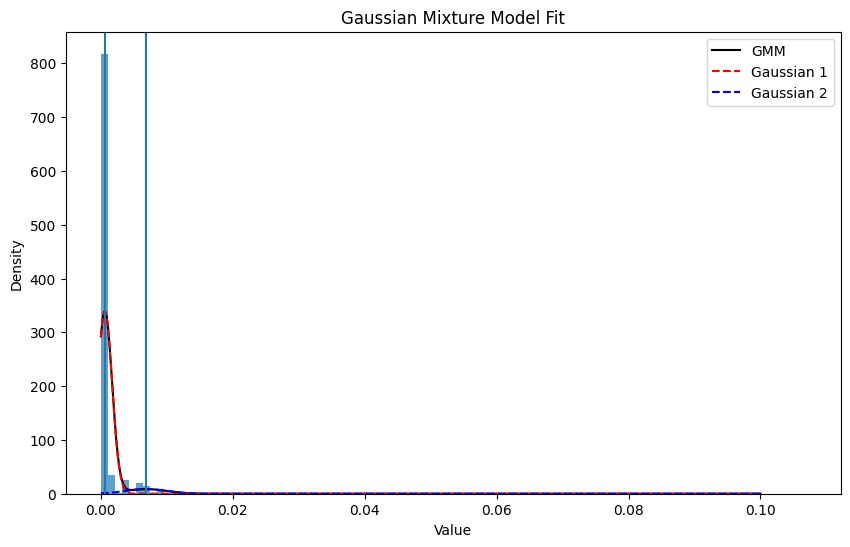

In [20]:
# Plot the qb_30ss
plt.figure(figsize=(10, 6))
plt.hist(flat_data, bins=100, density=True, alpha=0.7)
plt.plot(x, np.exp(logprob), 'k-', label='GMM')
plt.plot(x, np.exp(logprob) * responsibilities[:, 0], 'r--', label='Gaussian 1')
plt.plot(x, np.exp(logprob) * responsibilities[:, 1], 'b--', label='Gaussian 2')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
# plt.xlim(0, 0.1)
plt.title('Gaussian Mixture Model Fit')
# plt.gca().set_yscale('log')
# plt.ylim(1e-1, 1e2)

# Print the parameters of the two Gaussians
for i, (mean, covar) in enumerate(zip(gmm.means_, gmm.covariances_)):
    print(f'Gaussian {i+1}:')
    print(f'  Mean = {mean[0]:.6f}')
    print(f'  Std Dev = {np.sqrt(covar[0][0]):.6f}')
    print(f'  Weight = {gmm.weights_[i]:.6f}')
    plt.axvline(mean)
    
plt.show()
    

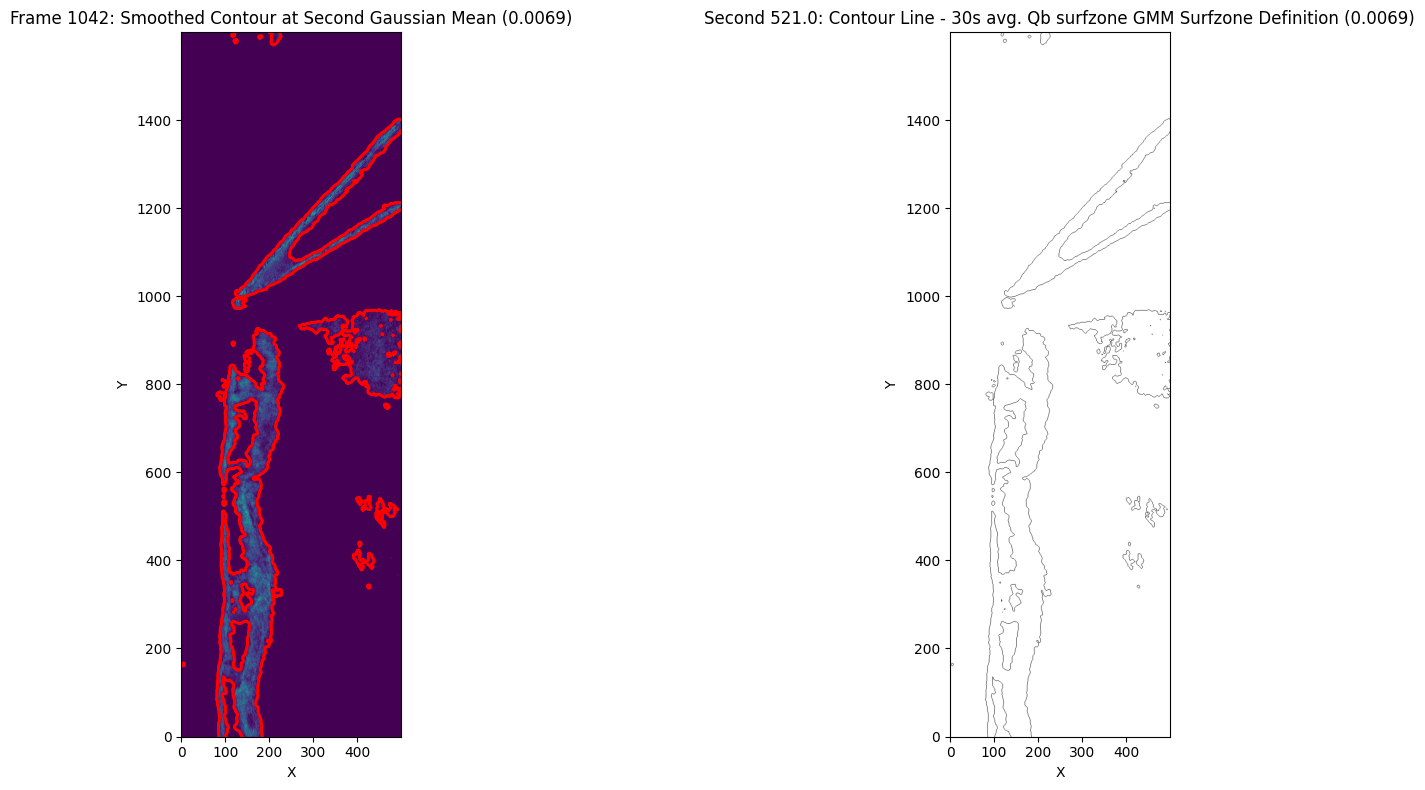

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy import ndimage as ndi

# Assuming qb_30s, mean, and covar are already defined

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
contour_lines = []
contours = np.zeros_like(breakers, dtype=bool)

contour_image = np.zeros_like(qb_30s[0], dtype=bool)
mean = gmm.means_[1][0]
covar = gmm.covariances_[1]

def update(frame):
    ax1.clear()
    ax2.clear()
    
    # Apply Gaussian smoothing to qb_30s[frame]
    smoothed_data = ndi.gaussian_filter(qb_30s[frame], sigma=2)
    
    # Create the contour
    contour = ax1.contour(smoothed_data, levels=[mean - 2 * np.sqrt(covar[0][0])], colors='red', linewidths=2)
    
    # Extract contour lines
    contour_lines = contour.allsegs[0]
    
    # Plot the original data
    im = ax1.imshow(qb_30s[frame], cmap='viridis')
    
    # Plot the smoothed contour lines
    for line in contour_lines:
        ax1.plot(line[:, 0], line[:, 1], color='red', linewidth=2)
    
    ax1.set_title(f'Frame {frame}: Smoothed Contour at Second Gaussian Mean ({mean:.4f})')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    
    # Create a binary image with the contour
    contour_image = np.zeros_like(qb_30s[frame], dtype=bool)
    for line in contour_lines:
        rr, cc = np.round(line[:, 1]).astype(int), np.round(line[:, 0]).astype(int)
        contour_image[rr, cc] = True
    contours[frame] = contour_image
    
    # Plot the contour as a binary image
    ax2.imshow(contour_image, cmap='binary')
    ax2.set_title(f'Second {frame/FPS}: Contour Line - 30s avg. Qb surfzone GMM Surfzone Definition ({mean:.4f})')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    
    return ax1, ax2

# Create the animation
anim = FuncAnimation(fig, update, frames=len(qb_30s), interval=1, blit=False)

# Save the animation (uncomment the line below to save)
anim.save('contour_evolution.mp4', writer='ffmpeg', fps=5)

plt.tight_layout()
plt.show()

In [36]:
write_sequence_to_mp4(normalize(qb_30s.astype(np.uint8)), 'qb_30s.mp4')

KeyboardInterrupt: 

In [37]:
surfzone_extent = contours.shape[2] - np.argmax(np.flip(contours, axis=2), axis=2) - 1

Text(0, 0.5, 'Cross-shore Surf Zone Onset')

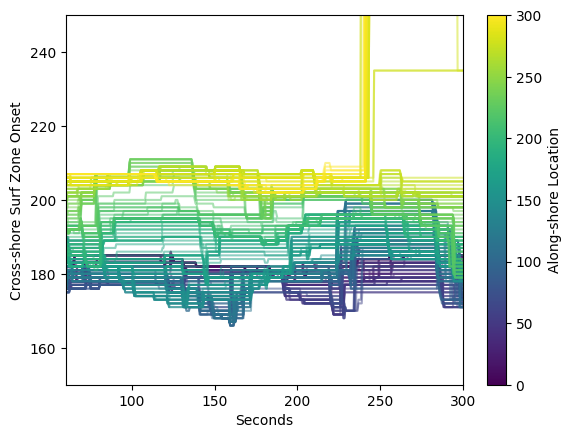

In [45]:
ymin=0
ymax=300

fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0, 1, ymax-ymin))

for i, y in enumerate(np.arange(ymin, ymax)):
    ax.plot(np.arange(len(surfzone_extent))/2, surfzone_extent[:, y], c=colors[i], alpha=0.5)

norm = Normalize(vmin=ymin, vmax=ymax)
sm = ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Along-shore Location')


plt.xlim(60, 300)
plt.ylim(150, 250)
plt.xlabel('Seconds')
plt.ylabel('Cross-shore Surf Zone Onset')

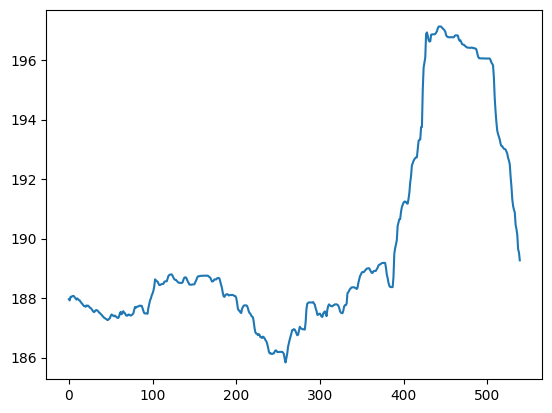

In [46]:
plt.plot(np.mean(surfzone_extent[60:600, 0:300], axis=1))

(340, 100)
(340,)
(340,)


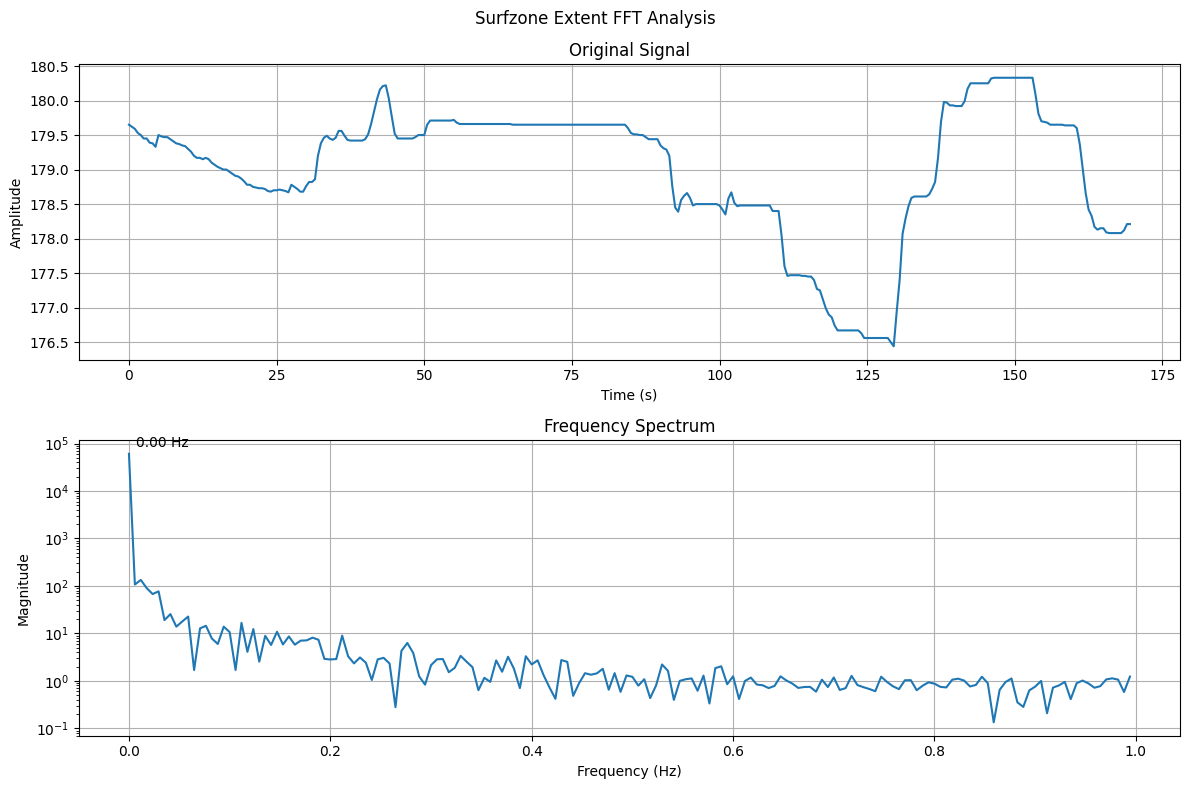

In [63]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fft_analysis(signal, sampling_rate=1.0, title="Signal FFT Analysis"):
    """
    Compute and plot the FFT of a signal, showing both the original signal
    and its frequency spectrum.
    
    Parameters:
    -----------
    signal : array-like
        The input time-series signal
    sampling_rate : float
        The sampling rate of the signal in Hz (default=1.0)
    title : str
        Title for the plot
    """
    # Compute the FFT
    n = len(signal)
    fft_result = np.fft.fft(signal)
    freqs = np.fft.fftfreq(n, d=1/sampling_rate)
    
    # Compute magnitude spectrum (take positive frequencies only)
    magnitude = np.abs(fft_result)[:n//2]
    freqs = freqs[:n//2]
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(title)
    
    # Plot original signal
    print(signal.shape)
    time = np.arange(len(signal)) / sampling_rate
    ax1.plot(time, signal)
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude')
    ax1.set_title('Original Signal')
    ax1.grid(True)
    
    # Plot FFT
    ax2.semilogy(freqs, magnitude)
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Magnitude')
    ax2.set_title('Frequency Spectrum')
    ax2.grid(True)
    # If there are dominant frequencies, mark them
    peak_threshold = np.max(magnitude) * 0.5
    peaks = magnitude > peak_threshold
    for freq, mag in zip(freqs[peaks], magnitude[peaks]):
        ax2.annotate(f'{freq:.2f} Hz', 
                    xy=(freq, mag),
                    xytext=(5, 5),
                    textcoords='offset points')
    
    plt.tight_layout()
    return fig, (ax1, ax2)

# Example usage with your specific case:
def analyze_surfzone_extent(data, sampling_rate=1.0):
    """
    Analyze the mean of surfzone extent data and plot its FFT.
    
    Parameters:
    -----------
    data : array-like
        The surfzone_extent array
    sampling_rate : float
        The sampling rate of the data in Hz
    """
    # Calculate mean along specified dimensions
    print(data.shape)
    mean_signal = np.mean(data, axis=1)
    print(mean_signal.shape)
    
    # Plot FFT analysis
    return plot_fft_analysis(mean_signal, 
                           sampling_rate=sampling_rate,
                           title="Surfzone Extent FFT Analysis")

# Example of how to use it with your data:
sampling_rate = 2.0  # Replace with your actual sampling rate
fig, axes = analyze_surfzone_extent(surfzone_extent[60:400, 0:100], sampling_rate=sampling_rate)
plt.show()

In [55]:
surfzone_extent.shape

(1043, 1600)

In [ ]:
signal